# Lecture 5 — Equilibrium: Steady-State and Transition Dynamics

**Computational Methods for Heterogeneous-Agent Macro**

Jeffrey Sun


## 1. Setup

In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
using HouseholdStages, Plots, Printf, Accessors, LinearAlgebra

  Activating project at `~/projects/research/CV is all you need`


## 2. The Aiyagari model in `HouseholdStages`

At this stage (ha ha), we want to build a complete model and clearly distinguish it from the household block alone.

To that end, we build a data structure `AiyagariParams` that contains all the parameters of the complete model. The model has the same three-stage block as L03, plus a Cobb-Douglas firm which defines the equilibrium relationship between $K$ and $R$.

(We switch to using the `HouseholdStages.jl` package, which provides optimized stage implementations.)

It is important to note that `hh` solves steady state *as a function of* `env`. At a high level, `hh` can be thought of as providing:
- A function from `env` to steady state moments.
- A function from `env, V_end, Λ_start` to `V_start, Λ_end`, and contemporaneous moments.

Steady-state and transitional equilibria can be thought of as **outer loops** around that household block.

### 2.1 Parameters

In [2]:
@kwdef struct AiyagariParams
    β::Float64 = 0.96
    σ::Float64 = 1.5
    α::Float64 = 0.36
    δ::Float64 = 0.08
    A::Float64 = 1.0
    z_grid::Vector{Float64} = [0.6, 1.0, 1.4]
    Π_z::Matrix{Float64}    = [0.7 0.2 0.1;
                               0.2 0.6 0.2;
                               0.1 0.2 0.7]
    N_w::Int       = 400
    w_min::Float64 = 0.0
    w_max::Float64 = 100.0
end

function markov_stationary_mean(Π_z::AbstractMatrix, z_grid::AbstractVector)
    v = real.(eigvecs(Π_z')[:, end])
    return stat_mean = z_grid ⋅ (v ./ sum(v))
end

markov_stationary_mean (generic function with 1 method)

### Supply Side

The supply side is really a system of equations, but computationally we typically only
represent them with a number of functions representing those relationships.

Here we essentially have one function $K \mapsto w$, one function mapping $K \mapsto R$ and its inverse $R \mapsto K$. (Taking $L$ and parameters as exogenous.)

In general, we often choose one particular set of functions which form a directed acyclic graph (DAG), (including `env` $mapsto$ `moments` functions provided by the household block), which collide at some  outputs, and then use various methods to solve the resulting rootfinding problem.

In this case, we will pick a function $R \mapsto (K, w)$ given by the supply side, $R \mapsto K^\text{supplied}$ given by the household block, and then solve for $R$ such that $K^\text{supplied} = K$.

In [3]:
"Compute wage in the Aiyagari model as the marginal product of labour."
aiyagari_wage(K, L, α, A) = A*(1-α)*(K/L)^α

"""
Compute the supply side of the Aiyagari model, here formulated as a function taking R |-> K, w.
"""
function aiyagari_supply_side(R, p::AiyagariParams)
    (; α, δ, A, Π_z, z_grid) = p

    L = markov_stationary_mean(Π_z, z_grid)
    K = ((R-1+δ)/(A*α))^(1/(α-1)) * L

    @assert R ≈ A*α*(K/L)^(α-1) + 1 - δ

    return (;K, w=aiyagari_wage(K, L, α, A))
end

"""
Another formulation, taking K |-> R, w.
"""
function aiyagari_prices(K, p::AiyagariParams)
    (; α, δ, A, Π_z, z_grid) = p

    L = markov_stationary_mean(Π_z, z_grid)
    R = A*α*(K/L)^(α-1) + 1 - δ

    return (;R, w=aiyagari_wage(K, L, α, A))
end

aiyagari_prices

### 2.2 Layout and household chain

Three stages, in time order:

1. **Markov productivity shock** — `MarkovStage` along the `:z` axis.
2. **Receive income** — `WealthChangeStage`, with the wealth change given by $b' = (1+r)\,b + w\cdot z$.
3. **Consumption-savings choice** — `ConsumptionSavingsStage` with CRRA utility.

We compose them with `∘`, then call `define_moments!` to specify that $K'$ should equal aggregate end-of-period wealth.

In [4]:
# Define household state space:
# Axis 1: wealth $b$ on a log grid.
# Axis 2: productivity $z$ on the given z_grid.
aiyagari_layout(p) = StateLayout(
    StateAxis(:wealth, continuous_grid(p.w_min, p.w_max; length=p.N_w, spacing=:log)),
    StateAxis(:z, p.z_grid),
)

# CRRA utility function
_u_crra(c, ::Val{1}) = log(c)
_u_crra(c, ::Val{σ}) where σ = (c^(1 - σ)) / (1 - σ)
u_crra(c, valσ) = c < 0 ? -Inf : _u_crra(c, valσ)

# Define the household block as a composition of three stages, defining the K_supplied moment.
function aiyagari_household(p::AiyagariParams)
    layout = aiyagari_layout(p)

    # Stage 1 — Markov productivity shock
    z_shock = MarkovStage(layout; axis=:z, transition=p.Π_z)

    # Stage 2 — Receive income
    income = WealthChangeStage(layout; wealth_post=(cell; env) -> env.R * cell.wealth + env.w * cell.z)

    # Stage 3 — Consumption-savings
    savings = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c; env) -> u_crra(c, Val(p.σ)), monotone_search=:divide_conquer)

    # Compose in time order — leftmost runs first
    hh = z_shock ∘ income ∘ savings

    # Attach the K_supplied moment (aggregate wealth integral at end of chain)
    return define_moments!(hh; K_supplied=at_end(integrand=:wealth, reduce=sum))
end

aiyagari_household (generic function with 1 method)

### 2.3 What does `hh` look like?

Mathematically, any composition of Stages is itself a Stage. `hh` is therefore a `ChainStage`.

Any `AbstractStage`, including `ChainStage`, is a wrapper around two objects:
1. A Spec, containing pure configuration (layouts,
transition matrix, closures, attached moments)
2. A Buffer, containing "state" (scratch arrays, warm-start V/Λ, kernel cache for the forward pass).

Users need never touch the Buffer directly. This layout just makes the implementation nice and clean.

In [5]:
hh = aiyagari_household(AiyagariParams())
dump(hh; maxdepth=1)

ChainStage{HouseholdStages.ChainStageSpec{Tuple{HouseholdStages.MarkovStageSpec{Matrix{Float64}, Float64}, HouseholdStages.WealthChangeStageSpec{var"#aiyagari_household##0#aiyagari_household##1"{var"#aiyagari_household##2#aiyagari_household##3"}, Val{:linear}}, HouseholdStages.ConsumptionSavingsStageSpec{var"#aiyagari_household##4#aiyagari_household##5"{var"#aiyagari_household##6#aiyagari_household##7"{AiyagariParams}}, Float64, Val{:divide_conquer}}}}, HouseholdStages.ChainStageBuffer{Tuple{StageBuffer{Nothing, HouseholdStages.MarkovScratch{Matrix{Float64}}, Matrix{Float64}, Matrix{Float64}, StateLayout{(:wealth, :z), Tuple{StateAxis{:wealth, ContinuousGrid{Float64, Vector{Float64}}}, StateAxis{:z, DiscreteFinite{Float64, Vector{Float64}}}}}, StateLayout{(:wealth, :z), Tuple{StateAxis{:wealth, ContinuousGrid{Float64, Vector{Float64}}}, StateAxis{:z, DiscreteFinite{Float64, Vector{Float64}}}}}}, StageBuffer{HouseholdStages.WealthChangeKernel{Matrix{Float64}}, HouseholdStages.WealthChan

### 2.4 Solving steady-state given `env`

`HouseholdStages.jl` provides a helper function `make_env(hh; ...)`.

In [6]:
p   = AiyagariParams()
hh  = aiyagari_household(p)

R_guess = 1.04

(;K, w) = aiyagari_supply_side(R_guess, p)
env = make_env(hh; R=R_guess, w)
res = solve_steady_state_given_env!(hh, env)

@printf "R_guess = %.4f, K_demanded = %.4f, K_supplied = %.4f\n" R_guess K res.moments.K_supplied
@printf "VFI iters: %d   Λ iters: %d\n" res.history.vfi_iters res.history.lambda_iters

R_guess = 1.0400, K_demanded = 5.5655, K_supplied = 14.1213
VFI iters: 411   Λ iters: 1330


### 2.5 Equilibrium steady state via tatonnement on R

This is an **outer loop** which computes the **equilibrium** steady state of the Aiyagari model by:
1. Guess $R$.
2. Use `hh` to solve for $K^\text{supplied}$ at that $R$.
3. Read off the price $R^\text{implied}$ that would make firms demand $K^\text{supplied}$.
4. Damped-update $R \leftarrow (1-s)\,R + s\, R^\text{implied}$ until $R = R^\text{implied}$.

**Note.** Tatonnement on prices is the right abstraction for general equilibrium: the household block is a price-taker, and the outer loop searches for the price that clears the market. Tatonnement on quantities (like $K$) happens to work here because Aiyagari's market is one-dimensional, but it does not generalize to multi-good or multi-asset models.


### 2.5 Equilibrium steady state via tatonnement on K

This is an **outer loop** which computes the **equilibrium** steady state of the Aiyagari model by:
1. Guessing $R$.
2. Using `hh` to solve for $K^\text{supplied}$, and the corresponding $R^\text{implied}$, as a function of $R$.
3. Updating $R$ until $R = R^\text{implied}$.

**Note:** This code is intended to demonstrate the method of tatonnement for finding market-clearing prices. In this particular case, it is technically true that you could solve for the equilibrium by iterating $K$ forward as you iterate $\Lambda$ forward, and computing $R$ from $K$. However, this is a quirk of the Aiyagari model and that method **does not work in general.**

In [7]:
"Solve for steady-state equilibrium by damped tatonnement on R."
function aiyagari_steady_state(p::AiyagariParams; R_init=1.04, update_speed=0.02, rtol=1e-4, maxiter=200, verbosity=0)
    local V, Λ, K

    # Build household block
    hh = aiyagari_household(p)
    R  = R_init

    err = Inf
    iters = 0
    while err >= rtol
        # Compute R_implied at current R by household steady state
        env = make_env(hh; R, w=aiyagari_supply_side(R, p).w)
        (;V, Λ, moments) = solve_steady_state_given_env!(hh, env)
        R_implied = aiyagari_prices(moments.K_supplied, p).R

        # Compute error
        err = abs(R_implied - R)
        
        # Update R
        R += update_speed*(R_implied - R)

        # Housekeeping
        verbosity >= 1 && @printf "  iter %d: R = %.5f, R_implied = %.5f, err = %.2e\n" iters R R_implied err
        iters = iters + 1
        iters > maxiter && error("aiyagari_steady_state did not converge in $maxiter iterations")
    end

    K = aiyagari_supply_side(R, p).K
    return (; R, K, V, Λ, iters)
end

aiyagari_steady_state

In [8]:
p = AiyagariParams()
ss = aiyagari_steady_state(p; verbosity=1, R_init=1.02)
@printf "\nK_ss = %.4f, R = %.5f, w = %.4f  (in %d outer iters)\n" ss.K ss.R aiyagari_supply_side(ss.R, p).w ss.iters

  iter 0: R = 1.02347, R_implied = 1.19330, err = 1.73e-01
  iter 1: R = 1.02645, R_implied = 1.17285, err = 1.49e-01
  iter 2: R = 1.02900, R_implied = 1.15361, err = 1.27e-01
  iter 3: R = 1.03113, R_implied = 1.13563, err = 1.07e-01
  iter 4: R = 1.03289, R_implied = 1.11899, err = 8.79e-02
  iter 5: R = 1.03430, R_implied = 1.10345, err = 7.06e-02
  iter 6: R = 1.03540, R_implied = 1.08963, err = 5.53e-02
  iter 7: R = 1.03626, R_implied = 1.07831, err = 4.29e-02
  iter 8: R = 1.03689, R_implied = 1.06788, err = 3.16e-02
  iter 9: R = 1.03736, R_implied = 1.06011, err = 2.32e-02
  iter 10: R = 1.03767, R_implied = 1.05276, err = 1.54e-02
  iter 11: R = 1.03787, R_implied = 1.04804, err = 1.04e-02
  iter 12: R = 1.03800, R_implied = 1.04438, err = 6.50e-03
  iter 13: R = 1.03809, R_implied = 1.04229, err = 4.29e-03
  iter 14: R = 1.03815, R_implied = 1.04128, err = 3.19e-03
  iter 15: R = 1.03819, R_implied = 1.04001, err = 1.86e-03
  iter 16: R = 1.03821, R_implied = 1.03906, err =

### 2.6 Comparative statics

Compute new equilibrium steady state resulting from permanent 5% positive TFP shock.

(In the new equilibrium, capital adjusts so that $R$ is ultimately unchanged at $1/\beta$.)

In [9]:
ss_old = aiyagari_steady_state(p)
p_new  = @set p.A = 1.05
ss_new = aiyagari_steady_state(p_new; R_init=ss_old.R)

@printf "ΔK = %+0.4f  (%.2f%%)\n" (ss_new.K - ss_old.K) 100*(ss_new.K/ss_old.K - 1)
@printf "old K_ss = %.4f   new K_ss = %.4f\n" ss_old.K ss_new.K
@printf "old R    = %.5f  new R    = %.5f\n" ss_old.R ss_new.R

ΔK = +0.4532  (7.96%)
old K_ss = 5.6951   new K_ss = 6.1483
old R    = 1.03824  new R    = 1.03822


## 3. MIT shock — perfect-foresight transition

**Given.** The exogenous path $\{A_t\}_{t=1}^T$, the household chain `hh`, and the firm $(\alpha, \delta, L)$.

**Find.** Sequences $\{R_t\}, \{V_t\}, \{\Lambda_t\}$ such that

- $V_{T+1} = V_{\mathrm{ss\_new}}$ (terminal condition),
- $\Lambda_1 = \Lambda_{\mathrm{ss\_old}}$ (initial condition),
- $V_t = \texttt{backward!}(V_{t+1}, \mathrm{env}_t)$ for $t = T, T{-}1, \ldots, 1$,
- $\Lambda_{t+1} = \texttt{forward!}(\Lambda_t, V_{t+1}, \mathrm{env}_t)$ for $t = 1, 2, \ldots, T$,
- $R_t = R^{\mathrm{implied}}(K_t^{\mathrm{supplied}})$ where $K_t^{\mathrm{supplied}} = \int b\,\mathrm{d}\Lambda_{t+1}$.

**Algorithm:**
1. Guess $\{R_t\}$
2. Iterate $V$ backward from $V_\text{ss\_new}$
3. Iterate $\Lambda$ forward from $\Lambda_\text{ss\_old}$
4. Compute $R_t^{\mathrm{implied}}$ from the supply side given $K_t^{\mathrm{supplied}}$
5. Update $R_t$ and repeat to convergence.

In [10]:
"Solve the MIT-shock transition by tatonnement on the R path."
function mit_shock_transition(p::AiyagariParams; A_new=1.05, T=100, update_speed=0.1, rtol=1e-5, maxiter=200, verbosity=0)
    # Compute endpoint steady states
    pre   = aiyagari_steady_state(p)
    p_new = @set p.A = A_new
    post  = aiyagari_steady_state(p_new; R_init=pre.R)

    # Construct household chain with post-shock parameters
    hh = aiyagari_household(p_new)

    # Initial R_path guess
    R_path  = collect(range(pre.R, post.R; length=T))

    err   = Inf
    iters = 0
    while err >= rtol
        # Construct env path and compute moments (R_implied) path using hh
        env_path = [make_env(hh; R=R_path[t], w=aiyagari_supply_side(R_path[t], p_new).w) for t in 1:T]
        (;moments_path) = solve_transition_given_env_path!(hh, env_path; Λ_0=pre.Λ, V_T=post.V)
        R_implied = [aiyagari_prices(m.K_supplied, p_new).R for m in moments_path]

        # Compute error
        err = maximum(abs.(R_implied .- R_path))

        # Update R_path
        R_path .+= update_speed .* (R_implied .- R_path)

        # Housekeeping
        verbosity >= 1 && @printf "  iter %d: ‖R_implied - R‖∞ = %.2e\n" iters err
        iters = iters + 1
        iters > maxiter && error("mit_shock_transition did not converge in $maxiter iterations")
    end

    K_path = [aiyagari_supply_side(R, p_new).K for R in R_path]
    return (; R_path, K_path, pre, post, p_new, iters)
end

mit_shock_transition

### 3.2 Manual Version — Unpacking `solve_transition_given_env_path!`

This is the same algorithm, just without using the library function `solve_transition_given_env_path!`.

It makes it clearer how the transition is actually computed.

In particular, it makes it clearer that a new `hh` must be allocated for each period, since the backwards pass generates cached information on the `hh` object that is used in the forward pass.

In [11]:
"Same as `mit_shock_transition` but with the backward/forward sweeps written out by hand."
function mit_shock_transition_manual(p::AiyagariParams; A_new=1.05, T=100, update_speed=0.1, rtol=1e-5, maxiter=200, verbosity=0)
    # Endpoint steady states
    pre   = aiyagari_steady_state(p)
    p_new = @set p.A = A_new
    post  = aiyagari_steady_state(p_new; R_init=pre.R)

    # Allocate one hh per period
    hh_path = [aiyagari_household(p_new) for _ in 1:T]
    dims    = layout_size(aiyagari_layout(p_new))

    # Allocate paths and set boundary conditions
    V_path = [zeros(Float64, dims...) for _ in 1:T+1]
    Λ_path = [zeros(Float64, dims...) for _ in 1:T+1]
    copyto!(V_path[T+1], post.V) # V_path[T+1] = post.V  (terminal boundary)
    copyto!(Λ_path[1],   pre.Λ) # Λ_path[1]   = pre.Λ   (initial boundary)
    R_implied_path = zeros(T)

    # Initial R_path guess
    R_path  = collect(range(pre.R, post.R; length=T))
    
    err   = Inf
    iters = 0
    while err >= rtol
        # Construct env path
        env_path = [make_env(hh_path[t]; R=R_path[t], w=aiyagari_supply_side(R_path[t], p_new).w) for t in 1:T]

        # Iterate V backwards
        for t in T:-1:1
            copyto!(V_path[t], backward!(hh_path[t], V_path[t+1], env_path[t]))
        end

        # Simulate Λ forward and calculate moments
        for t in 1:T
            copyto!(Λ_path[t+1], forward!(hh_path[t], Λ_path[t]))
            K_S = compute_moments(hh_path[t], Λ_path[t+1], env_path[t]).K_supplied
            R_implied_path[t] = aiyagari_prices(K_S, p_new).R
        end

        # Compute error
        err = maximum(abs.(R_implied_path .- R_path))

        # Update R_path
        R_path .+= update_speed .* (R_implied_path .- R_path)

        verbosity >= 1 && @printf "  iter %d: ‖R_implied - R‖∞ = %.2e\n" iters err
        iters = iters + 1
        iters > maxiter && error("mit_shock_transition_manual did not converge in $maxiter iterations")
    end

    K_path = [aiyagari_supply_side(R, p_new).K for R in R_path]
    return (; R_path, K_path, V_path, Λ_path, pre, post, p_new, iters)
end


mit_shock_transition_manual

### 3.3 Capital IRF

The aggregate-capital path after the +5% TFP shock, with the pre-
and post-shock steady states marked as dashed horizontal lines.


  iter 0: ‖R_implied - R‖∞ = 5.89e-03
  iter 1: ‖R_implied - R‖∞ = 5.19e-03
  iter 2: ‖R_implied - R‖∞ = 4.61e-03
  iter 3: ‖R_implied - R‖∞ = 4.09e-03
  iter 4: ‖R_implied - R‖∞ = 3.65e-03
  iter 5: ‖R_implied - R‖∞ = 3.26e-03
  iter 6: ‖R_implied - R‖∞ = 2.90e-03
  iter 7: ‖R_implied - R‖∞ = 2.60e-03
  iter 8: ‖R_implied - R‖∞ = 2.32e-03
  iter 9: ‖R_implied - R‖∞ = 2.07e-03
  iter 10: ‖R_implied - R‖∞ = 1.85e-03
  iter 11: ‖R_implied - R‖∞ = 1.65e-03
  iter 12: ‖R_implied - R‖∞ = 1.47e-03
  iter 13: ‖R_implied - R‖∞ = 1.32e-03
  iter 14: ‖R_implied - R‖∞ = 1.19e-03
  iter 15: ‖R_implied - R‖∞ = 1.07e-03
  iter 16: ‖R_implied - R‖∞ = 9.54e-04
  iter 17: ‖R_implied - R‖∞ = 8.50e-04
  iter 18: ‖R_implied - R‖∞ = 7.65e-04
  iter 19: ‖R_implied - R‖∞ = 6.84e-04
  iter 20: ‖R_implied - R‖∞ = 6.16e-04
  iter 21: ‖R_implied - R‖∞ = 5.51e-04
  iter 22: ‖R_implied - R‖∞ = 4.96e-04
  iter 23: ‖R_implied - R‖∞ = 4.44e-04
  iter 24: ‖R_implied - R‖∞ = 3.99e-04
  iter 25: ‖R_implied - R‖∞ = 3.59e

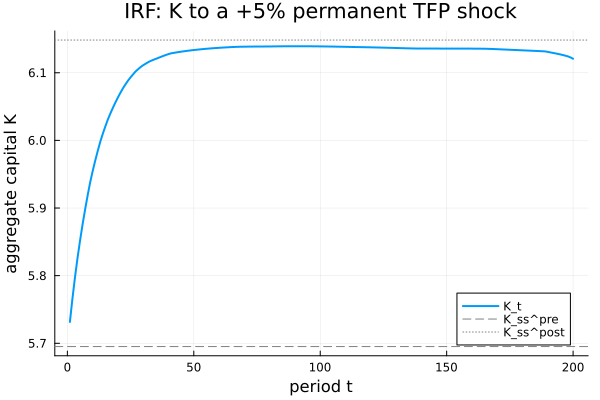

In [12]:
# Compute Transition
p = AiyagariParams()
T  = 200
tr = mit_shock_transition(p; A_new=1.05, T, verbosity=1, rtol=5e-5)
@printf "\nConverged in %d outer iters.\n" tr.iters
@printf "R_ss_pre  = %.5f,  R_ss_post = %.5f\n" tr.pre.R tr.post.R
@printf "K_ss_pre  = %.4f,  K_ss_post = %.4f\n" tr.pre.K tr.post.K
@printf "K[1] (impact) = %.4f\n" tr.K_path[1]
@printf "K[end]        = %.4f\n" tr.K_path[end]

# Plot capital IRF
plot(1:T, tr.K_path; lw=2, label="K_t",
     xlabel="period t", ylabel="aggregate capital K",
     title="IRF: K to a +5% permanent TFP shock")
hline!([tr.pre.K];  color=:gray, linestyle=:dash, label="K_ss^pre")
hline!([tr.post.K]; color=:gray, linestyle=:dot,  label="K_ss^post")

In [13]:
tr_manual = mit_shock_transition_manual(p; A_new=1.05, T, rtol=5e-5)
@printf "Manual converged in %d outer iters.\n" tr_manual.iters
@printf "‖R_path_clean - R_path_manual‖∞ = %.2e\n" maximum(abs.(tr.R_path .- tr_manual.R_path))


Manual converged in 47 outer iters.
‖R_path_clean - R_path_manual‖∞ = 0.00e+00


### 3.4 Interest-rate and wage paths

Note that there is some instability at the very end of the transition due to the $V_{T+1} = V_\text{ss\_new}$ being only an approximation.

However, the turnpike theorem tells us, approximately, that as long as the transition is long enough, not only does this not matter for early periods, but $V_{T+1}$ can actually be *anything* as long as $T$ is big enough!

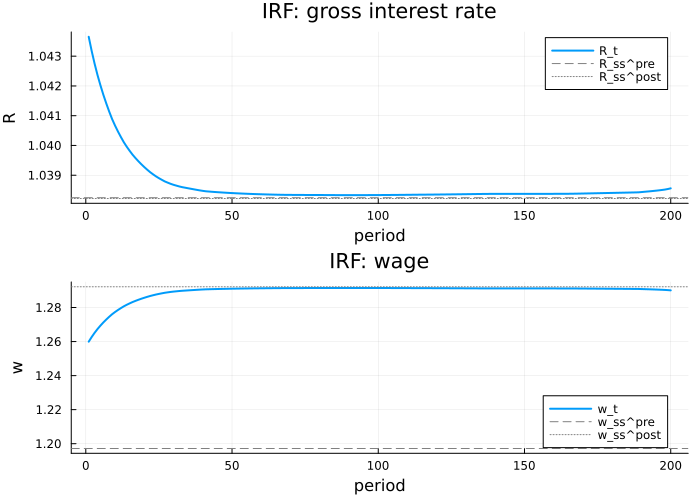

In [14]:
w_path = [aiyagari_supply_side(R, tr.p_new).w for R in tr.R_path]

plot(layout=(2, 1), size=(700, 500))
plot!(1:T, tr.R_path; subplot=1, lw=2, label="R_t",
      xlabel="period", ylabel="R", title="IRF: gross interest rate")
hline!([tr.pre.R];  subplot=1, color=:gray, linestyle=:dash, label="R_ss^pre")
hline!([tr.post.R]; subplot=1, color=:gray, linestyle=:dot,  label="R_ss^post")

plot!(1:T, w_path; subplot=2, lw=2, label="w_t",
      xlabel="period", ylabel="w", title="IRF: wage")
hline!([aiyagari_supply_side(tr.pre.R,  p       ).w]; subplot=2, color=:gray, linestyle=:dash, label="w_ss^pre")
hline!([aiyagari_supply_side(tr.post.R, tr.p_new).w]; subplot=2, color=:gray, linestyle=:dot,  label="w_ss^post")